# 実際の Polymarket の板でループ全体を通す

レシピ 05/07 は合成パネルの上でパイプラインを回すので、配管が通っていることは示せても、世界について
は何も示せません。こちらは実際のティックレベルの Polymarket データで回します。実際のマーケット、
実際の板、UMA で検証された実際の決着です。答えるのは、重要でありながら合成パネルには答えられない
問いです。標準的な規則のうち、実際の費用に耐えるものはあるのか。

ここでの答えは「ない」です。どの規則も損をし、その損は往復の回数についていきます。それこそが有益な
結果です。6マーケット1日ぶんで勝つ戦略を見せるチュートリアルは、自分をだます方法を教えることに
なります。ですからこのレシピは、ある規則が「機能しない」ことをどう確立するかに分量を使います。
機能すると信じるために必要な仕掛けは、まったく同じものです。

## ここで使う用語

| 用語 | 意味 |
| --- | --- |
| ティックレベルのデータ | 記録された板イベントのすべて。定期的な標本とは違う |
| 往復（round trip） | 1回の買いと、それを閉じる売り。費用が払われるのはここ |
| コスト予算 | 戦略が利益を出す前に越えなければならない費用の総額 |
| メイカー／テイカー | メイカーは指値を置いて待ち、テイカーはスプレッドを越えて即座に約定する |
| UMA | Polymarket がマーケットの決着に使う分散型オラクルのプロトコル |
| ホールドアウト | 最後まで手をつけずに取っておくデータ。使えるのは一度きり |
| デフレーテッド・シャープ | 試した候補の数だけ下方修正したシャープレシオ |
| ネガティブな結果 | 規則が機能しないことの確立。機能すると信じるのと同じ仕掛けを使う |

はじめて見る用語があれば、[GLOSSARY.ja.md](../../GLOSSARY.ja.md) にもう少し詳しい説明があります。ほかのレシピで使う用語もまとめてあります。

In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq

import cookbook_utils as cu
import h5i_db
from h5i_db import backtest, quant, venues

CACHE = Path("data/cache/kaggle-polymarket")
FEE_RATE = 0.07
QUANTITY = 50.0

## このデータと、このデータでないもの

範囲を限った、非商用の、ティックレベルの Polymarket 板のサンプルです。ここで再配布はしません。
ファイルがなければ、下のセルがダウンロードのコマンドを表示します。レシピ 04/04 と 04/05 と同じ
やり方です。

以下のすべてを形づくる制約が3つあります。3つとも h5i-db ではなく、この記録データの性質です。

In [2]:
missing = cu.kaggle_missing_files(CACHE)
if missing:
    print("This recipe needs the Kaggle sample. Missing:", missing)
    print(f"\nDataset: {cu.KAGGLE_POLYMARKET_DATASET}  (licence {cu.KAGGLE_POLYMARKET_LICENSE})")
    for line in cu.kaggle_download_commands(CACHE):
        print("  " + line)
    raise SystemExit("download the sample, then re-run")

snapshots = CACHE / "snapshots_2026-03-09.parquet"
targets_path = CACHE / "market_targets.parquet"
print(f"snapshots  {pq.ParquetFile(snapshots).metadata.num_rows:,} rows")
print(f"targets    {pq.ParquetFile(targets_path).metadata.num_rows:,} markets")
print(f"licence    {cu.KAGGLE_POLYMARKET_LICENSE} (non-commercial)")

snapshots  734,504 rows
targets    123,895 markets
licence    CC BY-NC 4.0 (non-commercial)


**1日ぶんであること。** 板の記録は1日ぶんで、対象のマーケットはたいていそれより後に決着するので、
決着まで持ち切れるものはほとんどありません。この研究は日中の話であり、注目すべき数値は
`settlement_pnl` ではなく `realized_pnl` です。実際に何マーケットが窓の内側で決着するかは、
仮定せずに下で計算します。「たいてい」は会計上の判断の根拠になりません。

**YES 側のみであること。** この記録が持つのは YES トークンの板だけで、NO トークンの板はありません。
そのためレシピ 05/01 のペア・パリティの取引はここでは検証できず、どの規則も YES の板で取引するしか
ありません。これも仮定せずに下で確認します。

**全板の深さがあること。** スナップショットは各サイド 150〜180 段を持ちます。ベスト気配を取る規則が
読むのはそのうち2段なので、このレシピではベスト気配に切り詰め、取り込み側が何段落としたかを正確に
報告します。

In [3]:
raw = pq.ParquetFile(snapshots)
sample = next(raw.iter_batches(batch_size=1, columns=["market_id", "update_type", "data"]))
event = json.loads(sample.to_pylist()[0]["data"])
print("one raw snapshot event carries:", sorted(event))
print(f"  side       {event['side']}")
print(f"  token_id   {str(event['token_id'])[:24]}...")
print(f"  bids/asks  {len(event['bids'])} / {len(event['asks'])} levels")
print(f"  first bid  {event['bids'][0]} (price, size as strings)")

one raw snapshot event carries: ['asks', 'best_ask', 'best_bid', 'bids', 'market_id', 'side', 'timestamp', 'token_id', 'update_type']
  side       YES
  token_id   445546811080747933138936...
  bids/asks  8 / 59 levels
  first bid  ['0.001', '11680'] (price, size as strings)


## 実在する、決着済みのマーケットを選ぶ

`market_targets.parquet` は、UMA で検証された結果とともに、1マーケット1行を持ちます。`target` は
`1 = YES の勝ち` と文書化されています。価格から推測せず、データセット自身の README から
取ることが、ラベルと当て推量の違いになります。

| 列 | 型 | 意味 |
|---|---|---|
| `condition_id` | `string` | マーケット。板の記録との結合キーでもある |
| `question` | `string` | 実際に取引されていた問い |
| `end_date` | `string` | ISO-8601。マーケットが閉じる時刻 |
| `closed` | `bool` | 取引が止まっているかどうか |
| `clob_token_id_yes` / `_no` | `string` | 結果ごとのトークン |
| `target` | `int8` | 1 = YES の勝ち、0 = NO の勝ち、null = 未決着 |

In [4]:
ids = pq.read_table(snapshots, columns=["market_id"]).column("market_id").combine_chunks()
coverage = pd.DataFrame(pc.value_counts(ids).to_pylist()).rename(
    columns={"values": "condition_id", "counts": "snapshot_rows"}
)
targets = pq.read_table(targets_path).to_pandas()
pool = coverage.merge(targets, on="condition_id").query("target.notna()")
print(f"markets in the capture:        {len(coverage):,}")
print(f"also defined in the labels:    {len(coverage.merge(targets, on='condition_id')):,}")
print(f"and resolved:                  {len(pool):,}")

chosen = pool.sort_values("snapshot_rows", ascending=False).head(6).reset_index(drop=True)
print()
print(chosen[["question", "snapshot_rows", "end_date", "target"]].to_string(index=False))

markets in the capture:        22,715


also defined in the labels:    12,733
and resolved:                  1,826

                                                                                        question  snapshot_rows             end_date  target
                                               Will Iran close the Strait of Hormuz by March 31?           2718 2026-12-31T00:00:00Z     1.0
                     Will there be no change in Fed interest rates after the March 2026 meeting?           1586 2026-03-18T00:00:00Z     1.0
                               Will Michael B. Jordan win Best Actor at the 98th Academy Awards?           1346 2026-03-15T00:00:00Z     1.0
                   Will the Fed decrease interest rates by 50+ bps after the March 2026 meeting?           1344 2026-03-18T00:00:00Z     0.0
Will The Greens win the second most seats in the 2026 Baden-Württemberg parliamentary elections?           1314 2026-03-08T00:00:00Z     0.0
                   Will the Fed increase interest rates by 25+ bps after the M

## 実際のラベルからマーケット定義を作る

`MarketSpec` は `outcome_labels` と `tokens` を位置で対応づけるので、YES トークンは `YES` ラベルと
同じインデックスになければなりません。逆にすると、すべての約定が反対のサイドに帰属します。だから
こそ、この仕様は曖昧に書けるやり方を拒否します。

In [5]:
specs = [
    venues.MarketSpec(
        instrument_id=row.condition_id,
        venue="polymarket",
        outcome_labels=("YES", "NO"),
        tokens=(row.clob_token_id_yes, row.clob_token_id_no),
        tick_size=0.001,
        lot_size=1.0,
        expiration_ns=int(pd.Timestamp(row.end_date).value),
        settlement_observable_ns=int(pd.Timestamp(row.end_date).value),
        winner_outcome=0 if int(row.target) == 1 else 1,
        metadata={"question": row.question},
    )
    for row in chosen.itertuples()
]
db = h5i_db.Database(cu.fresh_db("05_real_polymarket_end_to_end"), create=True)
markets = venues.write_markets(db, specs, note="UMA-verified labels")
print(f"instruments {markets.tables['instruments'].rows} rows "
      f"({len(specs)} markets x 2 outcomes)")
print(f"resolutions {markets.tables['resolutions'].rows} rows")
for spec in specs[:3]:
    print(f"  {spec.outcome_labels[spec.winner_outcome]:3} won: {spec.metadata['question'][:64]}")

instruments 12 rows (6 markets x 2 outcomes)
resolutions 6 rows
  YES won: Will Iran close the Strait of Hormuz by March 31?
  YES won: Will there be no change in Fed interest rates after the March 20
  YES won: Will Michael B. Jordan win Best Actor at the 98th Academy Awards


## 実際の板を取り込む

この記録は、WebSocket の受信をそのまま Parquet に書いたものです。イベントは1つの列に入った JSON
文字列で、トークンはその中にあります。ネストしたリストやフラットな行に並ぶ、3つめの形です。ですから
別のコード経路は要らず、もう1つの `ArchiveLayout` リテラルになります。

`max_levels=1` でベスト気配を残します。切り詰めはオプトインで、かつ報告されます。黙って浅くなった板は、
別の板だからです。

In [6]:
layout = venues.ArchiveLayout(
    name="kaggle-polymarket-top",
    timestamp_column="timestamp_received",
    timestamp_unit="ms",
    instrument_column="market_id",
    event_type_column="update_type",
    snapshot_events=("book_snapshot",),
    levels=venues.LevelLayout(style="payload"),
    payload_column="data",
    payload_token_field="token_id",
    payload_outcome_field="side",
    outcome_labels=("YES", "NO"),
    max_levels=1,
)
started = time.time()
ingest = venues.ingest_archive(
    db, files=[snapshots], markets=specs, layout=layout, note="tick capture, top of book"
)
print(f"ingested in {time.time() - started:.1f}s")
print(ingest)
for item in ingest.skipped:
    print(" ", json.dumps(item))
db.snapshot("real-v1", tables=["instruments", "book_deltas", "resolutions"],
            note="real Polymarket books, top of book")

ingested in 3.1s
IngestReport(vendor='kaggle-polymarket-top', book_deltas=19174, coverage=n/a, gaps=0, replayed=False)
  {"reason": "depth_truncated", "max_levels": 1, "levels_dropped": 1298277}


{'name': 'real-v1',
 'created_at_ns': 1785449511516021210,
 'note': 'real Polymarket books, top of book',
 'entries': {'66972e33-2cb7-4f05-87c8-23de970a9f6b': {'table_name': 'book_deltas',
   'sequence': 1,
   'manifest_checksum': 'ecd55f3818838ce51f88e181b6e3f240a60d5863939d4f64b9903e22de902d81'},
  'd9c5130f-7ef6-4c5d-aac5-783ca450548b': {'table_name': 'resolutions',
   'sequence': 1,
   'manifest_checksum': 'e2d0a21c1fd0cc3789c687106e4db5d4b8d5be29c87e1ae5561e631f5d67a532'},
  'e4525841-cf9e-4f83-b1b5-1c3cf8f70a43': {'table_name': 'instruments',
   'sequence': 1,
   'manifest_checksum': '53296492f0e323860a205bd6ea6181abe9b1822fc4675561e996ea9f1a387af7'}},
 'checksum': '1432d8b245ba614861bff34ced7da8de0ed699c79025db6f2db2a31ab8a1ec7b'}

YES 側だけという主張を、断言せずに確認します。板を持つのは outcome 0 だけなので、これらのマーケット
の NO 側はこの研究では取引できません。

In [7]:
sides = db.sql(
    """
    SELECT outcome, count(DISTINCT event_index) AS events,
           count(DISTINCT instrument_id) AS markets,
           min(price) AS low, max(price) AS high
    FROM book_deltas GROUP BY outcome ORDER BY outcome
    """
).to_pandas()
print(sides.to_string(index=False))
malformed = db.sql(
    """
    SELECT count(*) AS malformed FROM (
        SELECT event_index FROM book_deltas GROUP BY event_index
        HAVING count(DISTINCT outcome) > 1
            OR sum(CASE WHEN is_last THEN 1 ELSE 0 END) <> 1)
    """
).to_pandas()
print(f"\nmalformed book events: {int(malformed.malformed.iloc[0])}")

 outcome  events  markets   low  high
       0    9588        6 0.001  0.99

malformed book events: 0


## これらの板が作るパネル

実際のスプレッドが並びますが、一様ではありません。0.002 で取引されているマーケットと 0.47 で
取引されているマーケットは、どちらも1契約とはいえ、執行の観点では別の銘柄です。

In [8]:
panel = backtest.quote_panel(db, snapshot="real-v1")
panel["spread"] = panel.ask - panel.bid
panel["mid"] = (panel.bid + panel.ask) / 2
print(f"{len(panel):,} quote rows across {panel.instrument_id.nunique()} markets")
print(panel[["bid", "ask", "spread", "mid"]].describe().round(4).to_string())
print("\nhalf-spread as a share of the mid, by price level:")
levels = panel.assign(level=lambda f: f.mid.round(1)).groupby("level").agg(
    quotes=("mid", "size"),
    half_spread=("spread", lambda s: s.mean() / 2),
)
levels["half_spread_pct_of_mid"] = levels.half_spread / levels.index * 100
print(levels.round(4).to_string())

9,576 quote rows across 6 markets
             bid        ask     spread        mid
count  9574.0000  9576.0000  9574.0000  9574.0000
mean      0.5163     0.5211     0.0049     0.5187
std       0.4462     0.4438     0.0164     0.4449
min       0.0010     0.0020     0.0010     0.0025
25%       0.0030     0.0040     0.0010     0.0035
50%       0.4720     0.4740     0.0010     0.4730
75%       0.9800     0.9820     0.0030     0.9810
max       0.9880     0.9900     0.4710     0.9890

half-spread as a share of the mid, by price level:
       quotes  half_spread  half_spread_pct_of_mid
level                                             
0.0      3467       0.0015                     inf
0.1       239       0.0207                 20.7092
0.2       147       0.0354                 17.7007
0.3        77       0.0199                  6.6255
0.5      1138       0.0014                  0.2869
0.6       204       0.0036                  0.6054
0.7         4       0.0266                  3.8036
1.0  

## パック全体を走らせる

11の規則、1つのピン、1つの手数料モデル、ほかは何も変えません。順位づけは `realized_pnl` で行います。
ここでは何も決済されないからです。その日を越えて残ったポジションはすべて未決着なので、閉じた往復
だけが誠実な採点表になります。

In [9]:
started = time.time()
results = {}
rows = []
for name, generator in sorted(backtest.STRATEGIES.items()):
    plan = generator(panel)
    if not plan.num_signals:
        rows.append({"strategy": name, "signals": 0, "fills": 0, "realized_pnl": None})
        continue
    table = f"signals_{name}"
    db.create_table(table, plan.signals.schema, time_column="ts")
    db.append(table, plan.signals)
    result = backtest.execute(
        db,
        backtest.BacktestConfig(
            run_id=f"pack-{name}",
            data=backtest.DataConfig(signals=table, snapshot="real-v1"),
            portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
            execution=backtest.ExecutionConfig(fee_kind="kalshi", fee_rate=FEE_RATE),
            output=backtest.OutputConfig(equity_interval_nanos=60 * 1_000_000_000),
            metadata=plan.to_metadata(),
        ),
    )
    results[name] = result
    summary = result.summary()
    rows.append(
        {
            "strategy": name,
            "signals": plan.num_signals,
            "fills": summary["fills"],
            "realized_pnl": summary["realized_pnl"],
            "fees": summary["commissions"],
        }
    )
board = pd.DataFrame(rows).sort_values("realized_pnl", ascending=False, na_position="last")
print(f"{len(results)} runs in {time.time() - started:.1f}s\n")
print(board.to_string(index=False))

11 runs in 3.4s

             strategy  signals  fills  realized_pnl     fees
           panic_fade       10      0      0.000000  0.00000
       vwap_reversion       34      0      0.000000  0.00000
           deep_value        3      2     -0.020000  0.02000
   late_favorite_hold        2      2     -0.040000  0.04000
   threshold_momentum       70      6     -1.245691  0.80726
             breakout      139    103     -6.360000  6.10866
final_period_momentum      190    130     -9.784377  7.68529
        ema_crossover      284    210    -13.927068 12.51379
       mean_reversion      342    268    -22.248978 18.46734
        rsi_reversion      741    557    -47.563349 40.09065
 microprice_imbalance     1188    855    -78.743539 67.92667


どの規則も損をし、その順序は取引回数にほぼ単調についていきます。11個の別々の悪い着想というより、費用の
問題の形です。往復のたびにスプレッドと手数料を払うので、最も多く取引した規則が最も多く払います。

In [10]:
traded = board.dropna(subset=["realized_pnl"])
traded = traded[traded.fills > 0].assign(
    pnl_per_fill=lambda f: f.realized_pnl / f.fills,
    fee_per_fill=lambda f: f.fees / f.fills,
)
print(traded[["strategy", "fills", "pnl_per_fill", "fee_per_fill"]].round(4).to_string(index=False))
correlation = traded.fills.corr(traded.realized_pnl)
print(f"\ncorrelation between trade count and P&L: {correlation:+.3f}")

             strategy  fills  pnl_per_fill  fee_per_fill
           deep_value      2       -0.0100        0.0100
   late_favorite_hold      2       -0.0200        0.0200
   threshold_momentum      6       -0.2076        0.1345
             breakout    103       -0.0617        0.0593
final_period_momentum    130       -0.0753        0.0591
        ema_crossover    210       -0.0663        0.0596
       mean_reversion    268       -0.0830        0.0689
        rsi_reversion    557       -0.0854        0.0720
 microprice_imbalance    855       -0.0921        0.0794

correlation between trade count and P&L: -0.997


## お金がどこへ行ったか

エンジンが実際に生んだ約定からの分解です。テイカーは建てるときにスプレッドの半分、閉じるときに
もう半分を払い、さらに両方のレグで取引所の手数料を払います。この予算を実現損失と比べると、その規則が
運が悪かったのか、単に高くついただけなのかが分かります。

In [11]:
worst = board.dropna(subset=["realized_pnl"]).iloc[-1].strategy
fills = results[worst].fills.to_pandas()
# A fill is stamped at the event that matched it, which need not be a quote
# instant, so this is an as-of join backwards onto the book it met.
paired = pd.merge_asof(
    fills.sort_values("ts"),
    panel[["instrument_id", "ts", "bid", "ask", "mid"]].sort_values("ts"),
    on="ts",
    by="instrument_id",
    direction="backward",
)
matched = paired.dropna(subset=["bid", "ask"])
print(f"fills matched to a quote: {len(matched)} of {len(paired)}")
paired["half_spread_cost"] = (paired.ask - paired.bid).abs() / 2 * paired.quantity
budget = pd.DataFrame(
    [
        {"component": "fees paid", "cost": float(fills.commission.sum())},
        {"component": "half spread crossed", "cost": float(paired.half_spread_cost.sum())},
    ]
)
budget.loc[len(budget)] = {"component": "total cost", "cost": budget.cost.sum()}
budget.loc[len(budget)] = {
    "component": "realized P&L",
    "cost": float(results[worst].summary()["realized_pnl"]),
}
gross = float(budget.loc[budget.component == "total cost", "cost"].iloc[0]) + float(
    results[worst].summary()["realized_pnl"]
)
budget.loc[len(budget)] = {"component": "implied gross edge", "cost": gross}
print(f"{worst}, {len(fills)} fills:")
print(budget.round(2).to_string(index=False))

fills matched to a quote: 855 of 855
microprice_imbalance, 855 fills:
          component   cost
          fees paid  67.93
half spread crossed  13.64
         total cost  81.57
       realized P&L -78.74
 implied gross edge   2.82


最後の行を読んでください。費用と損失が数パーセント以内で一致しているので、含意されるグロスのエッジは
ほぼゼロです。本物のシグナルがあったうえで費用に負けたのではありません。シグナルがなく、費用だけを
払ったということです。「有望だが高すぎる」とは別の診断であり、算術が支持するのはこちらのほうです。本物の
グロスのエッジがある規則なら、グロスの数値がはっきり正になり、損失はコスト予算より小さくなります。

## 最もましな規則を、誠実な仕掛けに通す

11の規則を順位づけて最良のものを走らせ直すのは探索であり、探索は選んだものを何であれ膨らませます。
ショートリストのホールドアウトを使ったウォークフォワードと、試した数に対するデフレーテッド・シャープ
が、「これが一番ましだった」を弁護できる主張に変えてくれます。

In [12]:
# "Least bad" is meaningless when it is won by a rule that barely trades:
# `late_favorite_hold` fires twice, so of course it loses least, and a
# walk-forward over it would score empty windows. Rank among rules that traded
# enough for a fold to contain trades, and say what the cut was.
MIN_FILLS = 30
eligible = board.dropna(subset=["realized_pnl"]).query("fills >= @MIN_FILLS")
excluded = board.dropna(subset=["realized_pnl"]).query("fills < @MIN_FILLS")
best_name = eligible.iloc[0].strategy
print(f"rules with at least {MIN_FILLS} fills: {len(eligible)}")
print(f"excluded as too quiet to score: {list(excluded.strategy)}")
print(f"best among the rest: {best_name} "
      f"({int(eligible.iloc[0].fills)} fills, {eligible.iloc[0].realized_pnl:+.2f})")
stamps = list(
    db.sql("SELECT DISTINCT ts_init FROM book_deltas ORDER BY ts_init").to_pandas().ts_init
)
cuts = [0, len(stamps) // 3, len(stamps) // 2, 2 * len(stamps) // 3, len(stamps) - 1]
walk = backtest.WalkForward.of(
    backtest.ValidationWindows(train=(stamps[cuts[0]], stamps[cuts[1]]),
                               holdout=(stamps[cuts[1]], stamps[cuts[2]])),
    backtest.ValidationWindows(train=(stamps[cuts[2]], stamps[cuts[3]]),
                               holdout=(stamps[cuts[3]], stamps[cuts[4]])),
)
study = backtest.study(
    db,
    study_id="real-fees",
    base=backtest.BacktestConfig(
        run_id="real-fees",
        data=backtest.DataConfig(signals=f"signals_{best_name}", snapshot="real-v1"),
        portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
        execution=backtest.ExecutionConfig(fee_kind="kalshi", fee_rate=FEE_RATE),
        output=backtest.OutputConfig(equity_interval_nanos=60 * 1_000_000_000),
    ),
    parameters={"execution.fee_rate": [0.0, 0.02, FEE_RATE]},
    validation=walk,
    selection=backtest.TopK(k=2, metric="realized_pnl"),
)
columns = ["trial", "parameters", "train_median_realized_pnl", "holdout_median_realized_pnl"]
print(pd.DataFrame(study.ranked())[columns].to_string(index=False))
print(f"\ntrials {len(study.trials)}, reached the holdout {len(study.selected)}")

rules with at least 30 fills: 6
excluded as too quiet to score: ['panic_fade', 'vwap_reversion', 'deep_value', 'late_favorite_hold', 'threshold_momentum']
best among the rest: breakout (103 fills, -6.36)


 trial                   parameters  train_median_realized_pnl  holdout_median_realized_pnl
     0  {"execution.fee_rate": 0.0}                  -0.330364                        0.180
     1 {"execution.fee_rate": 0.02}                  -0.870364                       -0.225

trials 3, reached the holdout 2


手数料をゼロにしても、この規則は利益を出しません。問題の所在がはっきりします。取引所の手数料体系では
なく、スプレッドのほうです。この区別が大事なのは、手数料は取引量で交渉できても、スプレッドは
交渉できないからです。

In [13]:
zero_fee = [
    row for row in study.trials
    if json.loads(row["parameters"])["execution.fee_rate"] == 0.0
]
if zero_fee:
    row = zero_fee[0]
    print(f"at fee 0.00: train median {row['train_median_realized_pnl']:+.2f}, "
          f"holdout median {row.get('holdout_median_realized_pnl', float('nan')):+.2f}")

at fee 0.00: train median -0.33, holdout median +0.18


In [14]:
equity = results[best_name].equity.to_pandas().sort_values("ts")
levels_ = equity.equity.tolist()
returns = [
    (levels_[i] - levels_[i - 1]) / levels_[i - 1]
    for i in range(1, len(levels_))
    if levels_[i - 1]
]
deflated = quant.deflated_sharpe(returns, trials=len(backtest.STRATEGIES))
print(f"observed Sharpe                 {deflated.sharpe:+.3f}")
print(f"benchmark after {deflated.trials} rules tried  {deflated.benchmark:+.3f}")
print(f"P(true Sharpe > benchmark)      {deflated.probability:.3f}")
print(f"\nthe search tried {len(backtest.STRATEGIES)} rules, so the bar the winner had")
print("to clear was raised accordingly, and it did not clear it")

observed Sharpe                 -0.144
benchmark after 11 rules tried  +0.047
P(true Sharpe > benchmark)      0.000

the search tried 11 rules, so the bar the winner had
to clear was raised accordingly, and it did not clear it


## ここでは決済が効かない。そしてエンジンがそう告げる

決済はポジションごとに行われ、1つの問いで制御されます。そのマーケットの結果が知り得るようになった
瞬間に、リプレイが到達したか。この6つのうち、記録の内側で決着するのは1つだけなので、それ以外の場所で
持っているポジションは決済できません。エンジンは最終的な勝者で評価する代わりに、拒否した1件ずつを
名指しします。どの実行がそれに当たるかは、各規則が引けの時点でどこをまだロングしていたかという事実
なので、断言せずに表にします。

`refused` 列を読んでください。フラグのほうではありません。`settlement_applied` は、決済が
「いずれかの」ポジションに届いたときに真になります。ですから4件の拒否と並んで `True` が出るのは、混在したパネルではふつうの
ことで、矛盾ではありません。ポジションごとの正本の合図は、`bt_positions.settlement_pnl` が null か
どうかです。すべてのマーケットが同じ瞬間に決着するパネルではこの区別が隠れます。レシピ 05/05 が
フラグを全か無かとして扱えたのに、ここではそうできないのはそのためです。

In [15]:
capture_end = int(pd.Timestamp(panel.ts.max()).value)
inside = [s for s in specs if s.settlement_observable_ns <= capture_end]
print(f"markets resolving inside the capture: {len(inside)} of {len(specs)}")
for spec in inside:
    print(f"  {spec.metadata['question'][:58]}")
print()
audit = []
for name, result in sorted(results.items()):
    manifest = result.run.to_pandas().iloc[0]
    held = result.positions.to_pandas()
    audit.append(
        {
            "strategy": name,
            "open_positions": len(held),
            "settled": int(held.settlement_pnl.notna().sum()) if len(held) else 0,
            "settlement_applied": bool(manifest.settlement_applied),
        }
    )
audit = pd.DataFrame(audit)
audit["refused"] = audit.open_positions - audit.settled
print(audit.to_string(index=False))
print(f"\nsimulated through: {pd.Timestamp(int(manifest.simulated_through_ns), unit='ns')}")
refusing = [name for name, result in results.items()
            if isinstance(result.run.to_pandas().warnings.iloc[0], str)
            and result.run.to_pandas().warnings.iloc[0]]
if refusing:
    text = results[refusing[0]].run.to_pandas().warnings.iloc[0]
    print(f"\nexample refusal ({refusing[0]}):\n  {text.split(';')[0][:150]}")
else:
    print("\nno run held a position in a market that resolves after the capture")

markets resolving inside the capture: 1 of 6
  Will The Greens win the second most seats in the 2026 Bade

             strategy  open_positions  settled  settlement_applied  refused
             breakout               4        0               False        4
           deep_value               2        0               False        2
        ema_crossover               4        0               False        4
final_period_momentum               4        0               False        4
   late_favorite_hold               2        0               False        2
       mean_reversion               3        0               False        3
 microprice_imbalance               5        0               False        5
           panic_fade               0        0               False        0
        rsi_reversion               4        0               False        4
   threshold_momentum               1        0               False        1
       vwap_reversion               0        0           

## 実際のラベルがそれでも役に立つところ

決済には手が届きませんが、決着そのものが無用なわけではありません。「市場自身の」確率を採点できます。
データについての問いであって、戦略についての問いではありません。6マーケットでは何かを結論づけるには
あまりに少なすぎますが、ここでの主役は仕掛けのほうです。

In [16]:
final_quotes = panel.sort_values("ts").groupby("instrument_id").last()
outcomes = {
    spec.instrument_id: 1.0 if spec.winner_outcome == 0 else 0.0 for spec in specs
}
scored = final_quotes.assign(outcome=lambda f: f.index.map(outcomes)).dropna(
    subset=["mid", "outcome"]
)
parts = quant.brier_decomposition(scored.mid.tolist(), scored.outcome.tolist())
print(f"markets scored   {int(parts['observations'])}")
print(f"Brier            {parts['brier']:.4f}")
print(f"  reliability    {parts['reliability']:.4f}")
print(f"  resolution     {parts['resolution']:.4f}")
print(f"  uncertainty    {parts['uncertainty']:.4f}")
print(f"base rate        {parts['base_rate']:.3f}")
questions = {spec.instrument_id: spec.metadata["question"] for spec in specs}
print("\nlast quote against the realized outcome, per market:")
print(
    scored.assign(question=lambda f: [questions[key][:46] for key in f.index])[
        ["question", "mid", "outcome"]
    ]
    .sort_values("mid")
    .round(3)
    .to_string(index=False)
)
print("\nThese six were selected for having the most book activity, and that")
print("selection favours markets close to resolving. A near-certain market is")
print("easy to forecast, so read this Brier score as a property of the sample.")

markets scored   6
Brier            0.0269
  reliability    0.0268
  resolution     0.2500
  uncertainty    0.2500
base rate        0.500

last quote against the realized outcome, per market:
                                      question   mid  outcome
Will the Fed decrease interest rates by 50+ bp 0.002      0.0
Will the Fed increase interest rates by 25+ bp 0.004      0.0
Will The Greens win the second most seats in t 0.024      0.0
Will Michael B. Jordan win Best Actor at the 9 0.601      1.0
Will Iran close the Strait of Hormuz by March  0.966      1.0
Will there be no change in Fed interest rates  0.986      1.0

These six were selected for having the most book activity, and that
selection favours markets close to resolving. A near-certain market is
easy to forecast, so read this Brier score as a property of the sample.


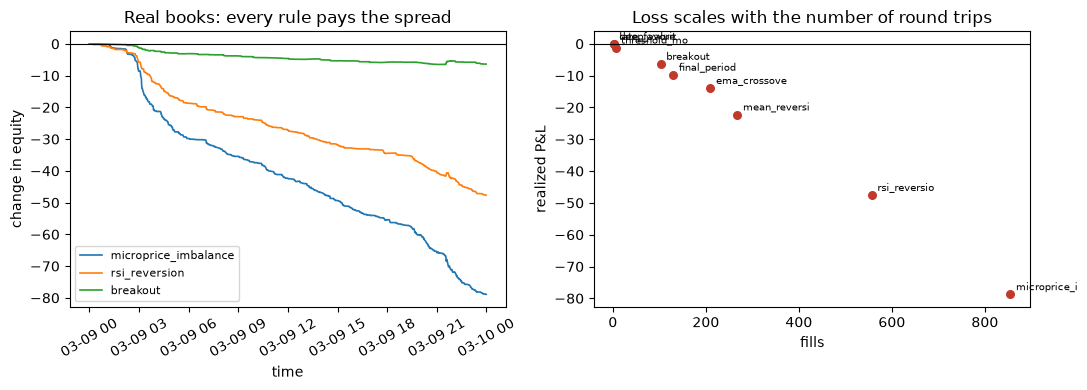

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in ("microprice_imbalance", "rsi_reversion", best_name):
    if name not in results:
        continue
    curve = results[name].equity.to_pandas().sort_values("ts")
    axes[0].plot(curve.ts, curve.equity - curve.equity.iloc[0], lw=1.2, label=name)
axes[0].axhline(0.0, color="black", lw=0.8)
axes[0].set_title("Real books: every rule pays the spread")
axes[0].set_xlabel("time")
axes[0].set_ylabel("change in equity")
axes[0].tick_params(axis="x", labelrotation=30)
axes[0].legend(fontsize=8)
axes[1].scatter(traded.fills, traded.realized_pnl, s=30, color="#c0392b")
for row in traded.itertuples():
    axes[1].annotate(row.strategy[:12], (row.fills, row.realized_pnl),
                     textcoords="offset points", xytext=(4, 3), fontsize=7)
axes[1].axhline(0.0, color="black", lw=0.8)
axes[1].set_title("Loss scales with the number of round trips")
axes[1].set_xlabel("fills")
axes[1].set_ylabel("realized P&L")
fig.tight_layout()

## 再現する

結果が何であれ成り立たなければならない、ただ1つの主張です。`verify()` は保存された設定を同じピンに
対して再実行し、すべての結果テーブルを1行ずつ突き合わせます。ネガティブな発見も、ポジティブな発見と
同じだけ再現できます。

In [18]:
verified = results[best_name].verify()
print(f"verified: {verified['verified']}")
print(f"tables compared: {list(verified['tables_equal'])}")
print(f"data pin: {results[best_name].config.data.snapshot}")
print(f"trial digest: {results[best_name].config.trial_digest[:16]}")

verified: True
tables compared: ['bt_orders', 'bt_fills', 'bt_positions', 'bt_equity']
data pin: real-v1
trial digest: 7894bbff3efefd12


## まとめ

- 実際の Polymarket の板では、11の定番規則がすべて費用後に損をし、その損は取引回数と相関する。
  安い規則はゆっくり損をし、最も忙しい規則が最も損をした。6マーケット1日ぶんでこれと違う結果を出す
  バックテストは、費用モデルに何かが欠けていると考えるべきである。
- コスト予算と損失が数パーセント以内で一致するので、含意されるグロスのエッジはほぼゼロである。これら
  の規則は、費用に食われるエッジを持っていたのではない。エッジがなく、費用だけを払った。「高すぎる」
  よりも鋭い診断であり、算術がそれを支持している。
- 手数料をゼロにしてもこの規則は損をするので、残る原因はスプレッドに絞られる。分けて考える価値が
  ある。手数料は取引量で交渉できるが、スプレッドは交渉できない。
- 記録データの制約が、そのまま研究の制約になる。1日ぶんなら何も決済されず、YES 側だけならパリティの
  取引はできず、全板の深さがあるならベスト気配への切り詰めを明示して報告することになる。3つとも
  データの性質であり、3つとも埋もれずに結果の中に見えている。
- ネガティブな結果にも、誠実な仕掛けは要る。11の規則を試したことは探索なので、勝者のシャープレシオは
  11試行に対して割り引かれ、基準を越えなかった。
- ここで働いた h5i-db の機能。新しいコードなしで JSON ペイロードの記録を読む `ArchiveLayout` の
  リテラル、黙って打ち切る代わりに報告される深さの切り詰め、11回の実行の背後にある1つのピン留め
  されたスナップショット、リプレイが到達しなかったものの決済を拒む観測可能性のゲート、そして
  ネガティブな発見を再現可能にする `verify()`。

In [19]:
db.close()